In [217]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [218]:
df = pd.read_excel("/kaggle/input/datasets/assadmehboob/cu-zn-on-anti-bactarial-properties/Green synthesis CU Zn on anti bactarial .xlsx")
df.head()

,Copper salt,Copper molarity,Zinc salt,Zinc molarity,cu zn Ratio,Plant name,Scintific,Temperature,Time,Mixing type,Crystal size,Sem particle size,Shape,Target Microorganism,Gram Status,Assay Type,Nanoparticle Dosage mg/L,Zone of Inhibition mm,Minimum Inhibitory Concentration ml
0,Copper sulfate,0.02,Zinc nitrate,0.02,1:1,Haddjod,Cissus quadrangularis,70.0,60.0,Water bath,14.79,32.4,NaN,Streptococcus mutans,Gram-positive,Agar well diffusion,NaN,17.00,NaN
1,Copper sulfate,0.02,Zinc nitrate,0.02,1:1,Haddjod,Cissus quadrangularis,70.0,60.0,Water bath,14.79,32.4,NaN,Staphylococcus aureus,Gram-positive,Agar well diffusion,NaN,21.00,NaN
2,Copper sulfate,0.02,Zinc nitrate,0.02,1:1,Haddjod,Cissus quadrangularis,70.0,60.0,Water bath,14.79,32.4,NaN,Bacillus subtilis,Gram-positive,Agar well diffusion,NaN,28.33,NaN
3,Copper sulfate,0.02,Zinc nitrate,0.02,1:1,Haddjod,Cissus quadrangularis,70.0,60.0,Water bath,14.79,32.4,NaN,Escherichia coli,Gram-negative,Agar well diffusion,NaN,26.33,NaN
4,Copper sulfate,0.02,Zinc nitrate,0.02,1:1,Haddjod,Cissus quadrangularis,70.0,60.0,Water bath,14.79,32.4,NaN,Pseudomonas aeruginosa,Gram-negative,Agar well diffusion,NaN,27.00,NaN


## Data Preprocessing

In [219]:
df= df.drop(columns=['Scintific'])

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Copper salt                          215 non-null    object 
 1   Copper molarity                      194 non-null    float64
 2   Zinc salt                            215 non-null    object 
 3   Zinc molarity                        194 non-null    float64
 4   cu zn Ratio                          50 non-null     object 
 5   Plant name                           220 non-null    object 
 6   Temperature                          110 non-null    float64
 7   Time                                 92 non-null     float64
 8   Mixing type                          142 non-null    object 
 9   Crystal size                         143 non-null    float64
 10  Sem particle size                    154 non-null    float64
 11  Shape                           

In [221]:
def fill_molarity_from_ratio(row):
    # Check if both molarity columns are NaN and the ratio column is not NaN
    if pd.isna(row['Copper molarity']) or pd.isna(row['Zinc molarity']) and pd.notna(row['cu zn Ratio']):
        try:
            # Split the string '1:1' or '7:3' by the colon
            cu_part, zn_part = str(row['cu zn Ratio']).split(':')
            
            # Convert to float, divide by 10, and update the row values
            row['Copper molarity'] = float(cu_part) / 10
            row['Zinc molarity'] = float(zn_part) / 10
        except (ValueError, AttributeError):
            # Handles edge cases if the ratio string is malformed (e.g., missing a colon)
            pass
            
    return row

# Apply the function across the rows of your DataFrame
df = df.apply(fill_molarity_from_ratio, axis=1)

In [222]:
# as cu zn Ratio small data apply to data set then drop the unuseful column 
df= df.drop(columns=['cu zn Ratio'])

In [223]:
df.duplicated().sum()

np.int64(3)

In [224]:
df = df.drop_duplicates()

In [225]:
df['Sem particle size'] = pd.to_numeric(df['Sem particle size'], errors='coerce')
df['Minimum Inhibitory Concentration ml'] = pd.to_numeric(df['Minimum Inhibitory Concentration ml'], errors='coerce')

In [226]:
# fill the missing value of catgerical data with the mode to avoid the loosing of features
fillna_mode = ['Copper salt', 'Zinc salt','Plant name','Mixing type','Shape','Target Microorganism', 'Gram Status', 'Assay Type']
for col in fillna_mode:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

In [227]:
# fill the missing value of numerical data with the mean to avoid the loosing of important features
fillna_mean = [ 'Temperature', 'Time', 'Crystal size', 'Sem particle size',"Zinc molarity","Copper molarity","Nanoparticle Dosage mg/L"]
for col in fillna_mean:
    df.loc[:, col] = df[col].fillna(df[col].mean())

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 240
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Copper salt                          238 non-null    object 
 1   Copper molarity                      238 non-null    float64
 2   Zinc salt                            238 non-null    object 
 3   Zinc molarity                        238 non-null    float64
 4   Plant name                           238 non-null    object 
 5   Temperature                          238 non-null    float64
 6   Time                                 238 non-null    float64
 7   Mixing type                          238 non-null    object 
 8   Crystal size                         238 non-null    float64
 9   Sem particle size                    238 non-null    float64
 10  Shape                                238 non-null    object 
 11  Target Microorganism                 

In [229]:
df.describe()

,Copper molarity,Zinc molarity,Temperature,Time,Crystal size,Sem particle size,Nanoparticle Dosage mg/L,Zone of Inhibition mm,Minimum Inhibitory Concentration ml
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,236.000000,116.000000
mean,0.115792,0.110814,73.504673,327.303371,19.929645,24.836184,1102.136646,17.465508,20.427612
std,0.100572,0.066765,19.041455,308.343559,2.911431,7.804176,549.347972,5.773208,24.599636
min,0.010000,0.010000,25.000000,10.000000,13.910000,7.110000,20.000000,6.000000,0.050000
25%,0.100000,0.100000,73.504673,120.000000,19.300000,23.400000,1000.000000,14.000000,1.560000
50%,0.100000,0.100000,73.504673,327.303371,19.929645,24.836184,1102.136646,17.500000,12.650000
75%,0.100000,0.100000,73.504673,327.303371,21.000000,26.300000,1102.136646,19.000000,31.250000
max,0.700000,0.500000,150.000000,1440.000000,32.540000,75.000000,2500.000000,53.000000,125.000000


In [230]:
df_num=df.select_dtypes(include=["number"])
df_txt=df.select_dtypes(exclude=["number"])

In [231]:
df_num.corr()

,Copper molarity,Zinc molarity,Temperature,Time,Crystal size,Sem particle size,Nanoparticle Dosage mg/L,Zone of Inhibition mm,Minimum Inhibitory Concentration ml
Copper molarity,1.000000,0.706652,-0.317634,-0.039317,-0.041312,-0.061490,-0.079392,-0.123837,-0.251133
Zinc molarity,0.706652,1.000000,-0.240794,-0.028578,0.021464,-0.104566,0.113931,-0.045631,-0.234602
Temperature,-0.317634,-0.240794,1.000000,-0.312236,0.094437,0.104029,0.153438,-0.140622,-0.029588
Time,-0.039317,-0.028578,-0.312236,1.000000,0.006827,0.140674,-0.117024,-0.094798,0.107737
Crystal size,-0.041312,0.021464,0.094437,0.006827,1.000000,0.329848,0.036338,-0.041994,-0.092774
Sem particle size,-0.061490,-0.104566,0.104029,0.140674,0.329848,1.000000,-0.147560,-0.016679,-0.050359
Nanoparticle Dosage mg/L,-0.079392,0.113931,0.153438,-0.117024,0.036338,-0.147560,1.000000,0.042115,0.104137
Zone of Inhibition mm,-0.123837,-0.045631,-0.140622,-0.094798,-0.041994,-0.016679,0.042115,1.000000,0.365501
Minimum Inhibitory Concentration ml,-0.251133,-0.234602,-0.029588,0.107737,-0.092774,-0.050359,0.104137,0.365501,1.000000


In [232]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
for col in df_txt:
    df[col] = df[col].astype(str)
    df[col] = lb.fit_transform(df[col])

## For Zone of Inhibition

In [233]:
df_zoi = df[df['Zone of Inhibition mm'].notna()]

In [234]:
df_zoi.shape

(236, 17)

In [235]:
x_zoi = df_zoi.drop(columns= ['Zone of Inhibition mm','Minimum Inhibitory Concentration ml'])
y_zoi = df_zoi['Zone of Inhibition mm']

In [236]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [237]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
xtrain_zoi,xtest_zoi,ytrain_zoi,ytest_zoi = train_test_split(x_zoi,y_zoi,test_size=0.25,random_state=42)

In [238]:
xtrain_zoi = ss.fit_transform(xtrain_zoi)
xtest_zoi = ss.transform(xtest_zoi)

In [252]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
)
dtr.fit(xtrain_zoi,ytrain_zoi)
dtr_pred_zoi = dtr.predict(xtest_zoi)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi,dtr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi,dtr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi,dtr_pred_zoi)}")
print("x"*30)
dtr_pred_zoi = dtr.predict(xtrain_zoi)
print("result from train data")
print(f"mean eror = {mean_absolute_error(ytrain_zoi,dtr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi,dtr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi,dtr_pred_zoi)}")

Result from test data
mean eror = 2.981980371268849
R2 = 0.34082046397719856
root mean eror = 4.0679220847985444
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
result from train data
mean eror = 3.219598030162382
R2 = 0.43115071315564446
root mean eror = 4.517033714021794


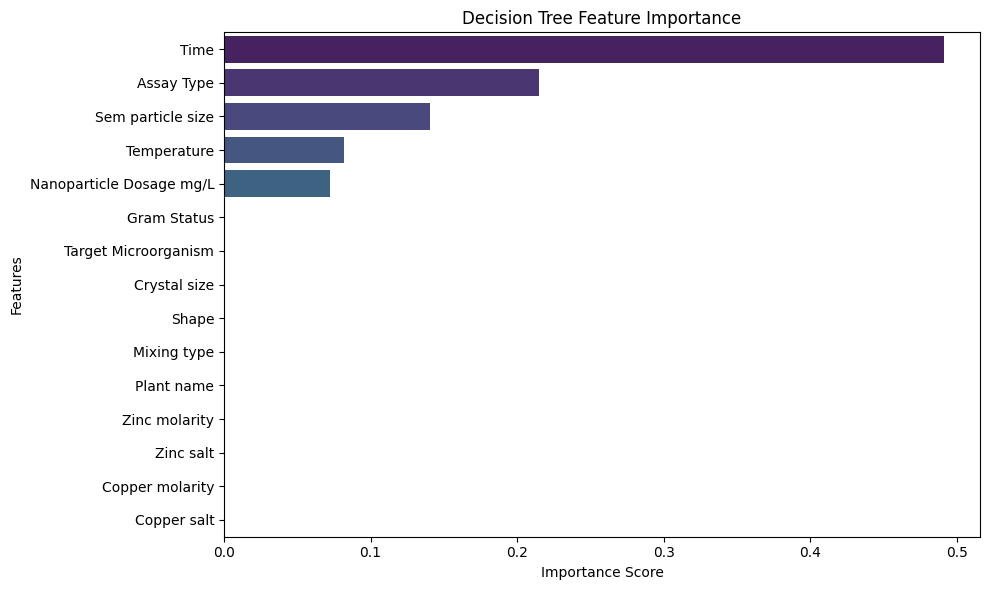

In [253]:
importances = dtr.feature_importances_

feature_names = x_zoi.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Decision Tree Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_tree_zoi.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()



In [254]:
#The final dataset for DTR after selecting the important features
x_zoi_dtr = x_zoi[['Temperature','Nanoparticle Dosage mg/L','Sem particle size','Time','Assay Type']]
xtrain_zoi_dtr,xtest_zoi_dtr,ytrain_zoi_dtr,ytest_zoi_dtr = train_test_split(x_zoi_dtr,y_zoi,test_size=0.25,random_state=42)
xtrain_zoi_dtr = ss.fit_transform(xtrain_zoi_dtr)
xtest_zoi_dtr = ss.transform(xtest_zoi_dtr)

In [268]:
dtr = DecisionTreeRegressor(
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
)
dtr.fit(xtrain_zoi_dtr,ytrain_zoi_dtr)
dtr_pred_zoi = dtr.predict(xtest_zoi_dtr)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi_dtr,dtr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi_dtr,dtr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi_dtr,dtr_pred_zoi)}")
print("x"*30)
dtr_pred_zoi = dtr.predict(xtrain_zoi_dtr)
print("result from train data")
print(f"mean eror = {mean_absolute_error(ytrain_zoi_dtr,dtr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi_dtr,dtr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi_dtr,dtr_pred_zoi)}")

Result from test data
mean eror = 2.761024236898301
R2 = 0.3852354080386081
root mean eror = 3.928485828192822
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
result from train data
mean eror = 2.943062197660148
R2 = 0.4349627575371209
root mean eror = 4.501873215265706


In [269]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(
    bootstrap = False,
    max_depth = 8,
    max_features = 'sqrt',
    min_samples_leaf = 4,
    min_samples_split = 8,
    n_estimators = 100,
)
rfr.fit(xtrain_zoi,ytrain_zoi)
rfr_pred_zoi = rfr.predict(xtest_zoi)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi,rfr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi,rfr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi,rfr_pred_zoi)}")
print("result from train data")
rfr_pred_zoi = rfr.predict(xtrain_zoi)
print(f"mean eror = {mean_absolute_error(ytrain_zoi,rfr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi,rfr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi,rfr_pred_zoi)}")

Result from test data
mean eror = 2.3553787868489717
R2 = 0.509962804857659
root mean eror = 3.5073999427004243
result from train data
mean eror = 2.245951341298262
R2 = 0.6978581688935901
root mean eror = 3.2920024632805847


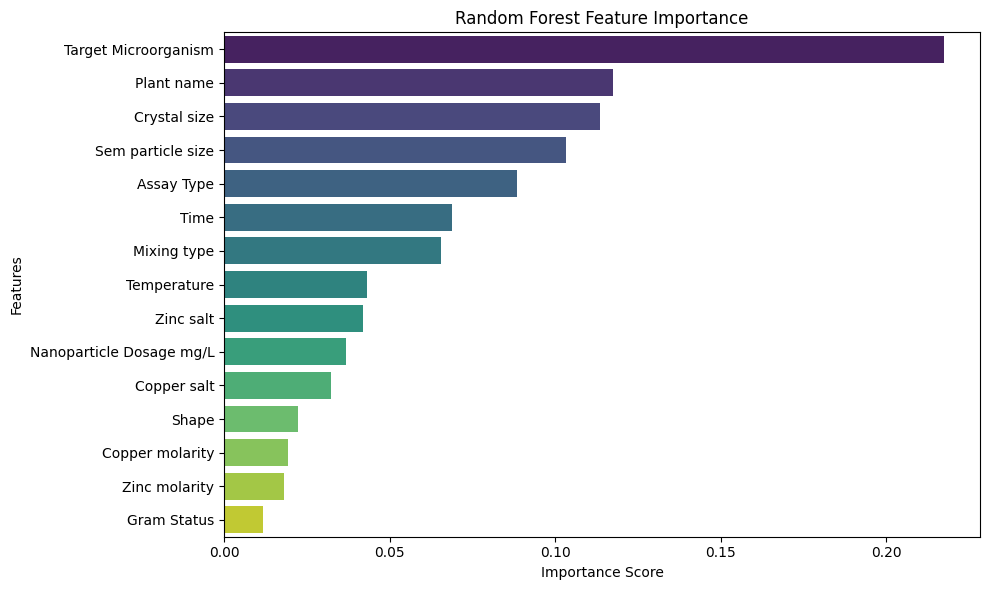

In [270]:
importances = rfr.feature_importances_

feature_names = x_zoi.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_rfr_zoi.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [273]:
#The final dataset for RFR after selecting the important features
x_zoi_rfr = x_zoi[['Plant name','Mixing type','Temperature','Target Microorganism','Time','Sem particle size','Crystal size','Assay Type']]
xtrain_zoi_rfr,xtest_zoi_rfr,ytrain_zoi_rfr,ytest_zoi_rfr = train_test_split(x_zoi_rfr,y_zoi,test_size=0.25,random_state=42)
xtrain_zoi_rfr = ss.fit_transform(xtrain_zoi_rfr)
xtest_zoi_rfr = ss.transform(xtest_zoi_rfr)

In [277]:
rfr = RandomForestRegressor(
    bootstrap = False,
    max_depth = 8,
    max_features = 'sqrt',
    min_samples_leaf = 4,
    min_samples_split = 8,
    n_estimators = 100,
)
rfr.fit(xtrain_zoi_rfr,ytrain_zoi_rfr)
rfr_pred_zoi = rfr.predict(xtest_zoi_rfr)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi_rfr,rfr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi_rfr,rfr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi_rfr,rfr_pred_zoi)}")
print("result from train data")
rfr_pred_zoi = rfr.predict(xtrain_zoi_rfr)
print(f"mean eror = {mean_absolute_error(ytrain_zoi_rfr,rfr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi_rfr,rfr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi_rfr,rfr_pred_zoi)}")

Result from test data
mean eror = 2.3022982252023994
R2 = 0.5356416949563363
root mean eror = 3.4142661825151275
result from train data
mean eror = 2.2642618761606315
R2 = 0.6988453691703538
root mean eror = 3.286620016432432


In [282]:
from sklearn.ensemble import AdaBoostRegressor
abr = AdaBoostRegressor(
    estimator=dtr, 
    n_estimators=10, 
    learning_rate=0.01,
)
abr.fit(xtrain_zoi,ytrain_zoi)
abr_pred_zoi = abr.predict(xtest_zoi)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi,abr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi,abr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi,abr_pred_zoi)}")
print("result from train data")
abr_pred_zoi = abr.predict(xtrain_zoi)
print(f"mean eror = {mean_absolute_error(ytrain_zoi,abr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi,abr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi,abr_pred_zoi)}")

Result from test data
mean eror = 2.5702355151855856
R2 = 0.4258566546038087
root mean eror = 3.7964784200153705
result from train data
mean eror = 2.686173689528115
R2 = 0.4780203599796744
root mean eror = 4.326946294570658


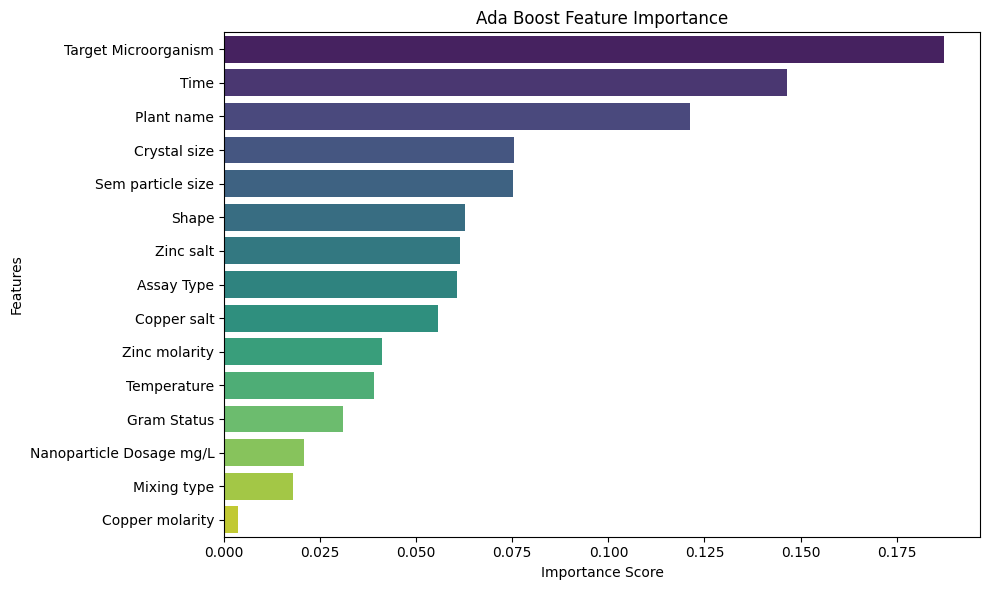

In [283]:
importances = abr.feature_importances_

feature_names = x_zoi.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Ada Boost Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_abr_zoi.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [286]:
#The final dataset for ABR after selecting the important features
x_zoi_abr = x_zoi[['Plant name', 'Shape','Copper salt','Zinc salt','Target Microorganism','Time','Copper salt','Sem particle size','Crystal size','Assay Type']]
xtrain_zoi_abr,xtest_zoi_abr,ytrain_zoi_abr,ytest_zoi_abr = train_test_split(x_zoi_abr,y_zoi,test_size=0.25,random_state=42)
xtrain_zoi_abr = ss.fit_transform(xtrain_zoi_abr)
xtest_zoi_abr = ss.transform(xtest_zoi_abr)

In [296]:
abr = AdaBoostRegressor(
    estimator=dtr, 
    n_estimators=10, 
    learning_rate=0.01,
)
abr.fit(xtrain_zoi_abr,ytrain_zoi_abr)
abr_pred_zoi = abr.predict(xtest_zoi_abr)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi_abr,abr_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi_abr,abr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi_abr,abr_pred_zoi)}")
print("result from train data")
abr_pred_zoi = abr.predict(xtrain_zoi_abr)
print(f"mean eror = {mean_absolute_error(ytrain_zoi_abr,abr_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi_abr,abr_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi_abr,abr_pred_zoi)}")

Result from test data
mean eror = 2.493707814933638
R2 = 0.475849922273631
root mean eror = 3.627426280502213
result from train data
mean eror = 2.7277012344936913
R2 = 0.5269617971667812
root mean eror = 4.119104700157238


In [300]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.01, 
    max_depth=6, 
    subsample=0.7,
)
xgb.fit(xtrain_zoi,ytrain_zoi)
xgb_pred_zoi = xgb.predict(xtest_zoi)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_zoi,xgb_pred_zoi)}")
print(f"R2 = {r2_score(ytest_zoi,xgb_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytest_zoi,xgb_pred_zoi)}")
print("result from train data")
xgb_pred_zoi = xgb.predict(xtrain_zoi)
print(f"mean eror = {mean_absolute_error(ytrain_zoi,xgb_pred_zoi)}")
print(f"R2 = {r2_score(ytrain_zoi,xgb_pred_zoi)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_zoi,xgb_pred_zoi)}")

Result from test data
mean eror = 2.425828259354931
R2 = 0.3990045741395487
root mean eror = 3.884242637023131
result from train data
mean eror = 2.363854599430063
R2 = 0.6288765208402127
root mean eror = 3.6484965381402032


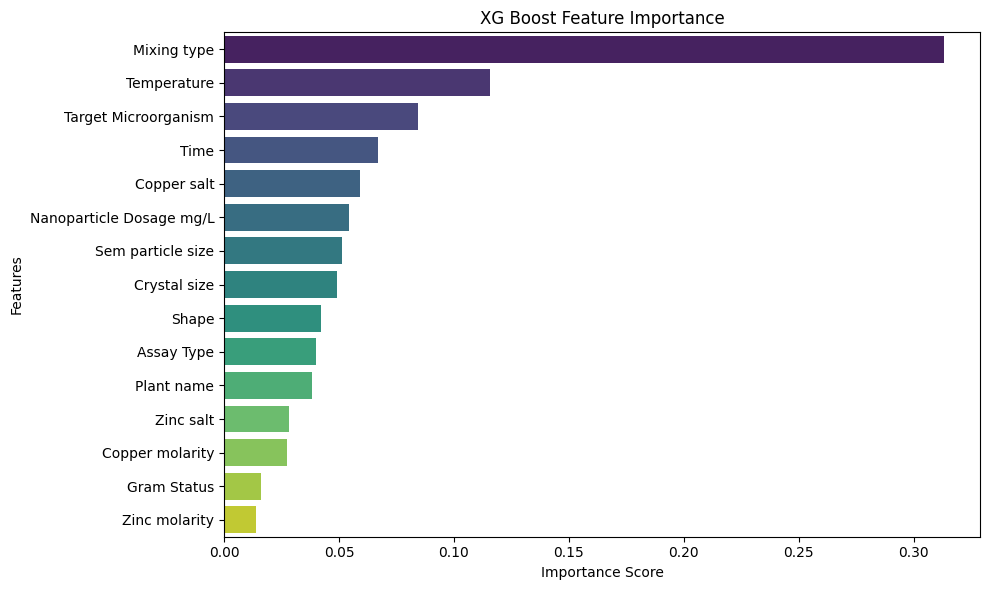

In [301]:
importances = xgb.feature_importances_

feature_names = x_zoi.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("XG Boost Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_xgb_zoi.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

## For Minimum Inhibitory Concentration

In [ ]:
df_mic = df[df['Minimum Inhibitory Concentration ml'].notna()]

In [ ]:
df_mic.shape

In [ ]:
x_mic = df_mic.drop(columns= ['Zone of Inhibition mm','Minimum Inhibitory Concentration ml'])
y_mic = df_mic['Minimum Inhibitory Concentration ml']

In [ ]:
xtrain_mic,xtest_mic,ytrain_mic,ytest_mic = train_test_split(x_mic,y_mic,test_size=0.25,random_state=42)

In [ ]:
xtrain_mic = ss.fit_transform(xtrain_mic)
xtest_mic = ss.transform(xtest_mic)

In [ ]:
ytrain_mic = np.log1p(ytrain_mic)
ytest_mic = np.log1p(ytest_mic)

In [330]:
dtr_mic = DecisionTreeRegressor(
    random_state=42,
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
)
dtr_mic.fit(xtrain_mic,ytrain_mic)
dtr_pred_mic = dtr_mic.predict(xtest_mic)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic,dtr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic,dtr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic,dtr_pred_mic)}")
print("Result from train data")
dtr_pred_mic = dtr_mic.predict(xtrain_mic)
print(f"mean eror = {mean_absolute_error(ytrain_mic,dtr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic,dtr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic,dtr_pred_mic)}")

Result from test data
mean eror = 0.6970926176354572
R2 = 0.4302899171526682
root mean eror = 0.9554337091080096
Result from train data
mean eror = 0.7668264972674891
R2 = 0.5324085423863822
root mean eror = 0.9827782048469772


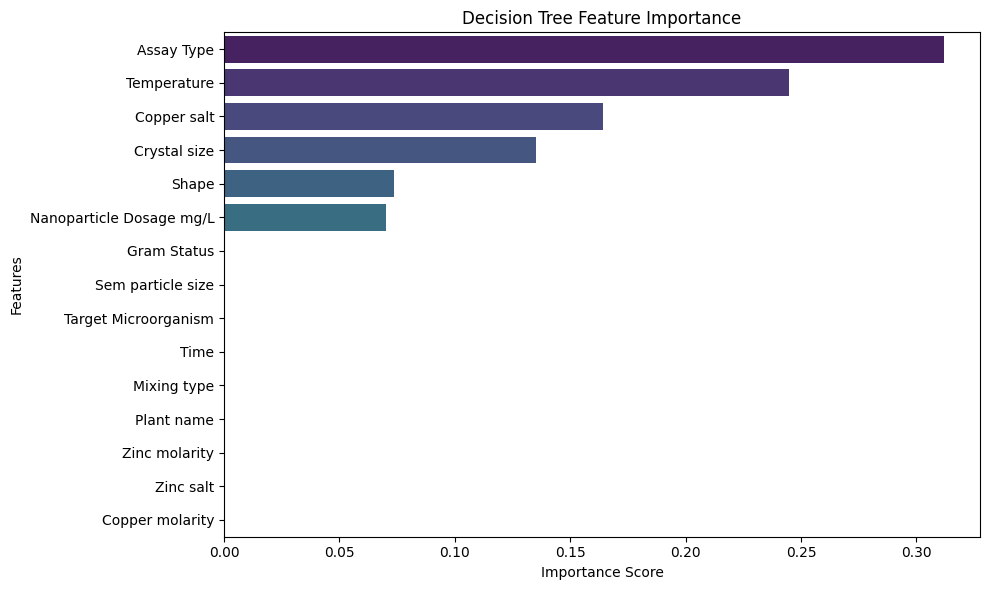

In [331]:
importances = dtr_mic.feature_importances_

feature_names = x_mic.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Decision Tree Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_tree_mic.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [335]:
#The final dataset for DTR after selecting the important features
x_mic_dtr = x_mic[['Assay Type','Temperature','Copper salt','Crystal size','Shape','Nanoparticle Dosage mg/L']]
xtrain_mic_dtr,xtest_mic_dtr,ytrain_mic_dtr,ytest_mic_dtr = train_test_split(x_mic_dtr,y_mic,test_size=0.25,random_state=42)
xtrain_mic_dtr = ss.fit_transform(xtrain_mic_dtr)
xtest_mic_dtr = ss.transform(xtest_mic_dtr)
ytrain_mic_dtr = np.log1p(ytrain_mic_dtr)
ytest_mic_dtr = np.log1p(ytest_mic_dtr)

In [337]:
dtr_mic = DecisionTreeRegressor(
    random_state=42,
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
)
dtr_mic.fit(xtrain_mic,ytrain_mic)
dtr_pred_mic = dtr_mic.predict(xtest_mic)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic,dtr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic,dtr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic,dtr_pred_mic)}")
print("Result from train data")
dtr_pred_mic = dtr_mic.predict(xtrain_mic)
print(f"mean eror = {mean_absolute_error(ytrain_mic,dtr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic,dtr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic,dtr_pred_mic)}")

Result from test data
mean eror = 0.6970926176354572
R2 = 0.4302899171526682
root mean eror = 0.9554337091080096
Result from train data
mean eror = 0.7668264972674891
R2 = 0.5324085423863822
root mean eror = 0.9827782048469772


In [338]:
rfr_mic = RandomForestRegressor(
    random_state=42,
    bootstrap = True,
    max_depth = 6,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 4,
    n_estimators = 200,
)
rfr_mic.fit(xtrain_mic,ytrain_mic)
rfr_pred_mic = rfr_mic.predict(xtest_mic)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic,rfr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic,rfr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic,rfr_pred_mic)}")
print("Result from train data")
rfr_pred_mic = rfr_mic.predict(xtrain_mic)
print(f"mean eror = {mean_absolute_error(ytrain_mic,rfr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic,rfr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic,rfr_pred_mic)}")

Result from test data
mean eror = 0.5208092594222454
R2 = 0.7113106115631062
root mean eror = 0.6801254357103277
Result from train data
mean eror = 0.4165760133895682
R2 = 0.8694300738384012
root mean eror = 0.5193304788653498


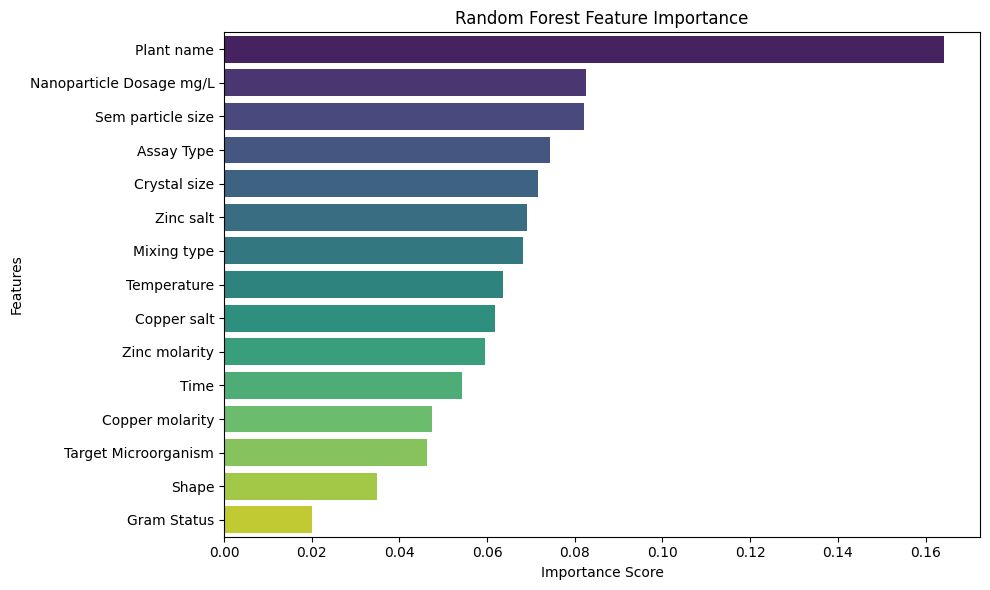

In [339]:
importances = rfr_mic.feature_importances_

feature_names = x_mic.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_rfr_mic.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [341]:
#The final dataset for RFR after selecting the important features
x_mic_rfr = x_mic.drop(columns=['Gram Status','Shape','Target Microorganism','Copper molarity',])
xtrain_mic_rfr,xtest_mic_rfr,ytrain_mic_rfr,ytest_mic_rfr = train_test_split(x_mic_rfr,y_mic,test_size=0.25,random_state=42)
xtrain_mic_rfr = ss.fit_transform(xtrain_mic_rfr)
xtest_mic_rfr = ss.transform(xtest_mic_rfr)
ytrain_mic_rfr = np.log1p(ytrain_mic_rfr)
ytest_mic_rfr = np.log1p(ytest_mic_rfr)

In [344]:
rfr_mic = RandomForestRegressor(
    random_state=42,
    bootstrap = True,
    max_depth = 6,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 4,
    n_estimators = 200,
)
rfr_mic.fit(xtrain_mic_rfr,ytrain_mic_rfr)
rfr_pred_mic = rfr_mic.predict(xtest_mic_rfr)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic_rfr,rfr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic_rfr,rfr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic_rfr,rfr_pred_mic)}")
print("Result from train data")
rfr_pred_mic = rfr_mic.predict(xtrain_mic_rfr)
print(f"mean eror = {mean_absolute_error(ytrain_mic_rfr,rfr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic_rfr,rfr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic_rfr,rfr_pred_mic)}")

Result from test data
mean eror = 0.49529355079525256
R2 = 0.7307663423525816
root mean eror = 0.6568077710859631
Result from train data
mean eror = 0.4160698415514232
R2 = 0.8715682716192192
root mean eror = 0.5150606787987072


In [353]:
abr_mic = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
    random_state=42,
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
), 
    n_estimators=100, 
    learning_rate=0.01, 
)
abr_mic.fit(xtrain_mic,ytrain_mic)
abr_pred_mic = abr_mic.predict(xtest_mic)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic,abr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic,abr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic,abr_pred_mic)}")
print("Result from train data")
abr_pred_mic = abr_mic.predict(xtrain_mic)
print(f"mean eror = {mean_absolute_error(ytrain_mic,abr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic,abr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic,abr_pred_mic)}")

Result from test data
mean eror = 0.6559160543540078
R2 = 0.5574228895652144
root mean eror = 0.8421085588593438
Result from train data
mean eror = 0.5630175207241489
R2 = 0.7581116689388088
root mean eror = 0.7068539533893861


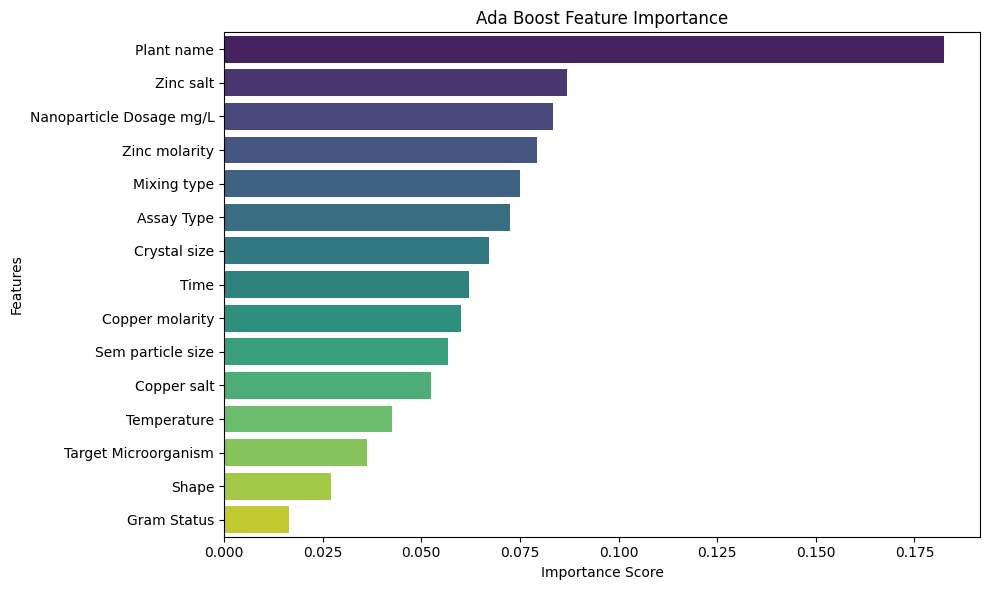

In [354]:
importances = abr_mic.feature_importances_

feature_names = x_mic.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Ada Boost Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_abr_mic.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [356]:
#The final dataset for ABR after selecting the important features
x_mic_abr = x_micx_mic_rfr = x_mic.drop(columns=['Gram Status','Shape','Zinc salt','Temperature','Target Microorganism'])
xtrain_mic_abr,xtest_mic_abr,ytrain_mic_abr,ytest_mic_abr = train_test_split(x_mic_abr,y_mic,test_size=0.25,random_state=42)
xtrain_mic_abr = ss.fit_transform(xtrain_mic_abr)
xtest_mic_abr = ss.transform(xtest_mic_abr)
ytrain_mic_abr = np.log1p(ytrain_mic_abr)
ytest_mic_abr = np.log1p(ytest_mic_abr)

In [361]:
abr_mic = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
    random_state=42,
    max_depth = 4,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 10,
), 
    n_estimators=100, 
    learning_rate=0.01, 
)
abr_mic.fit(xtrain_mic_abr,ytrain_mic_abr)
abr_pred_mic = abr_mic.predict(xtest_mic_abr)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic_abr,abr_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic_abr,abr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic_abr,abr_pred_mic)}")
print("Result from train data")
abr_pred_mic = abr_mic.predict(xtrain_mic_abr)
print(f"mean eror = {mean_absolute_error(ytrain_mic_abr,abr_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic_abr,abr_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic_abr,abr_pred_mic)}")

Result from test data
mean eror = 0.6041585702002016
R2 = 0.6224883825120939
root mean eror = 0.7777477572495552
Result from train data
mean eror = 0.5257518911704462
R2 = 0.7909074234787365
root mean eror = 0.6571908972498278


In [367]:
xgb_mic = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.01, 
    max_depth=4, 
    subsample=0.5,
    objective='reg:squarederror')
xgb_mic.fit(xtrain_mic,ytrain_mic)
xgb_pred_mic = xgb_mic.predict(xtest_mic)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic,xgb_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic,xgb_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic,xgb_pred_mic)}")
print("Result from train data")
xgb_pred_mic = xgb_mic.predict(xtrain_mic)
print(f"mean eror = {mean_absolute_error(ytrain_mic,xgb_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic,xgb_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic,xgb_pred_mic)}")

Result from test data
mean eror = 0.7145607123197346
R2 = 0.5467857798765636
root mean eror = 0.8521682923279534
Result from train data
mean eror = 0.7003713671153818
R2 = 0.6697750236828641
root mean eror = 0.8258994770923967


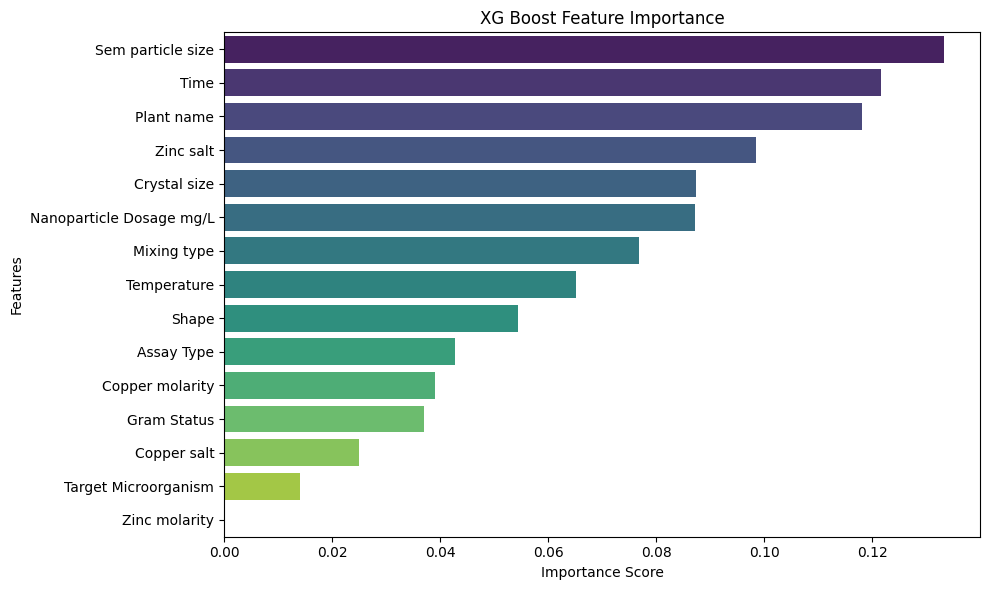

In [368]:
importances = xgb_mic.feature_importances_

feature_names = x_mic.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("XG Boost Feature Importance")

sns.barplot(
    x=importances[indices], 
    y=feature_names[indices], 
    palette="viridis"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("feature_importance_xgb_mic.png",format = "png", dpi=300, bbox_inches="tight")
plt.show()

In [370]:
#The final dataset for XGB after selecting the important features
x_mic_xgb = x_micx_mic_abr = x_micx_mic_rfr = x_mic.drop(columns=['Zinc molarity','Gram Status','Zinc salt','Copper salt','Target Microorganism'])
xtrain_mic_xgb,xtest_mic_xgb,ytrain_mic_xgb,ytest_mic_xgb = train_test_split(x_mic_xgb,y_mic,test_size=0.25,random_state=42)
xtrain_mic_xgb = ss.fit_transform(xtrain_mic_xgb)
xtest_mic_xgb = ss.transform(xtest_mic_xgb)
ytrain_mic_xgb = np.log1p(ytrain_mic_xgb)
ytest_mic_xgb = np.log1p(ytest_mic_xgb)

In [372]:
xgb_mic = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.01, 
    max_depth=4, 
    subsample=0.5,
    objective='reg:squarederror')
xgb_mic.fit(xtrain_mic_xgb,ytrain_mic_xgb)
xgb_pred_mic = xgb_mic.predict(xtest_mic_xgb)
print("Result from test data")
print(f"mean eror = {mean_absolute_error(ytest_mic_xgb,xgb_pred_mic)}")
print(f"R2 = {r2_score(ytest_mic_xgb,xgb_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytest_mic_xgb,xgb_pred_mic)}")
print("Result from train data")
xgb_pred_mic = xgb_mic.predict(xtrain_mic_xgb)
print(f"mean eror = {mean_absolute_error(ytrain_mic_xgb,xgb_pred_mic)}")
print(f"R2 = {r2_score(ytrain_mic_xgb,xgb_pred_mic)}")
print(f"root mean eror = {root_mean_squared_error(ytrain_mic_xgb,xgb_pred_mic)}")

Result from test data
mean eror = 0.6870397681791308
R2 = 0.5733250412820612
root mean eror = 0.8268413444183307
Result from train data
mean eror = 0.7047441076952583
R2 = 0.6695438313342138
root mean eror = 0.8261885349248084
